# Official RoBERTa Full-Dataset Coherence Model

This notebook trains the selected final model, `roberta-base`, on the full leak-free ROCStories split. It is intended as the official reproducible run for the graduation project.

Selection rationale: RoBERTa achieved the best transformer comparison result in the preliminary model comparison notebook, outperforming BERT, DistilBERT, DeBERTa, and all classical baselines on validation/test F1.


## Imports and Reproducibility


In [2]:
import json
import logging
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("official_roberta_full")


## Official Configuration


In [3]:
DATA_PATH = Path("ROCStories_winter2017 - ROCStories_winter2017 (2).csv")
OUTPUT_DIR = Path("outputs/official_roberta_full")
MODEL_NAME = "roberta-base"

SENT_COLS = [f"sentence{i}" for i in range(1, 6)]
MAX_LENGTH = 128
BATCH_SIZE = 16
MAX_EPOCHS = 5
EARLY_STOPPING_PATIENCE = 2
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
NEG_PER_POS = 1
TEST_SIZE = 0.15
VAL_SIZE = 0.15
NEGATIVE_STRATEGY = "shuffle"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Using device: %s", DEVICE)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "splits").mkdir(parents=True, exist_ok=True)


03:38:51 [INFO] Using device: cuda


## Data Preparation

The raw stories are split before negative generation to prevent versions of the same story appearing across train, validation, and test.


In [4]:
def make_negative(sentences, rng):
    negative = sentences[:]
    while negative == sentences:
        rng.shuffle(negative)
    return negative


def build_labeled_split(raw_df, seed):
    rng = random.Random(seed)
    records = []
    for story_id, row in raw_df.iterrows():
        sentences = [row[c] for c in SENT_COLS]
        records.append(
            {
                "story_id": row.get("storyid", story_id),
                "story": " [SEP] ".join(sentences),
                "label": 1,
                "negative_strategy": "original",
            }
        )
        for _ in range(NEG_PER_POS):
            negative = make_negative(sentences, rng)
            records.append(
                {
                    "story_id": row.get("storyid", story_id),
                    "story": " [SEP] ".join(negative),
                    "label": 0,
                    "negative_strategy": NEGATIVE_STRATEGY,
                }
            )
    return pd.DataFrame(records).sample(frac=1, random_state=seed).reset_index(drop=True)


In [5]:
raw_df = pd.read_csv(DATA_PATH)
missing = raw_df[SENT_COLS].isnull().sum().sum()
if missing:
    raise ValueError(f"Found {missing} missing sentence values.")

trainval_df, test_raw = train_test_split(raw_df, test_size=TEST_SIZE, random_state=SEED, shuffle=True)
val_relative = VAL_SIZE / (1 - TEST_SIZE)
train_raw, val_raw = train_test_split(trainval_df, test_size=val_relative, random_state=SEED, shuffle=True)

train_df = build_labeled_split(train_raw.reset_index(drop=True), SEED)
val_df = build_labeled_split(val_raw.reset_index(drop=True), SEED + 1)
test_df = build_labeled_split(test_raw.reset_index(drop=True), SEED + 2)

train_df.to_csv(OUTPUT_DIR / "splits" / "train.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "splits" / "val.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "splits" / "test.csv", index=False)

print(f"Raw stories: {len(raw_df):,}")
print(f"Train examples: {len(train_df):,}")
print(f"Validation examples: {len(val_df):,}")
print(f"Test examples: {len(test_df):,}")
train_df.head()


Raw stories: 52,665
Train examples: 73,730
Validation examples: 15,800
Test examples: 15,800


,story_id,story,label,negative_strategy
0,b4e397a7-bad8-4afb-8d1f-ac562f432a24,Leah and Kerry went to the beach in December. ...,1,original
1,fe04220c-a5c5-4ae6-be29-7b08bc3f10a2,They drove all night long with only a few stop...,0,shuffle
2,ebb1500d-51d8-403a-b576-a93ce702cd82,My physics teacher told us about the upcoming ...,1,original
3,71f37b7b-a95a-4356-9d5c-f00e9cfaf842,Her friend Oya likes romantic movies. [SEP] He...,0,shuffle
4,8ea02658-4a02-488b-ab50-33d39507d9b9,Jody was bringing home her newest baby from th...,0,shuffle


## Dataset and Metrics Helpers


In [6]:
class StoryDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=MAX_LENGTH,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long),
        }


def metric_dict(y_true, y_pred, y_score):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }


## Training and Evaluation Functions


In [7]:
def train_one_epoch(model, loader, optimizer, scheduler):
    model.train()
    total_loss = 0.0
    total = 0
    correct = 0

    for batch in tqdm(loader, desc="train", leave=False):
        optimizer.zero_grad(set_to_none=True)
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        preds = outputs.logits.argmax(dim=-1)
        total_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_preds, all_scores = [], [], []
    start = time.time()

    for batch in tqdm(loader, desc="eval", leave=False):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].numpy()

        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs = torch.softmax(logits, dim=-1)[:, 1].detach().cpu().numpy()
        preds = logits.argmax(dim=-1).detach().cpu().numpy()

        all_labels.extend(labels)
        all_preds.extend(preds)
        all_scores.extend(probs)

    return all_labels, all_preds, all_scores, time.time() - start


## Model Setup


In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

tokenizer.save_pretrained(OUTPUT_DIR / "tokenizer")

train_loader = DataLoader(
    StoryDataset(train_df["story"], train_df["label"], tokenizer),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    StoryDataset(val_df["story"], val_df["label"], tokenizer),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    StoryDataset(test_df["story"], test_df["label"], tokenizer),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * WARMUP_RATIO),
    num_training_steps=total_steps,
)

with open(OUTPUT_DIR / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(
        {
            "model_name": MODEL_NAME,
            "data_path": str(DATA_PATH),
            "output_dir": str(OUTPUT_DIR),
            "seed": SEED,
            "max_length": MAX_LENGTH,
            "batch_size": BATCH_SIZE,
            "max_epochs": MAX_EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "learning_rate": LEARNING_RATE,
            "warmup_ratio": WARMUP_RATIO,
            "weight_decay": WEIGHT_DECAY,
            "negative_strategy": NEGATIVE_STRATEGY,
            "neg_per_pos": NEG_PER_POS,
            "test_size": TEST_SIZE,
            "val_size": VAL_SIZE,
            "quick": False,
        },
        f,
        indent=2,
    )


03:39:03 [INFO] HTTP Request: HEAD https://huggingface.co/roberta-base/resolve/main/config.json "HTTP/1.1 200 OK"
03:39:03 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
03:39:03 [INFO] HTTP Request: HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
03:39:03 [INFO] HTTP Request: GET https://huggingface.co/api/models/roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
03:39:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
03:39:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/roberta-base/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
03:39:04 [INFO] HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-bas

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Official Training Run

The model trains for up to 5 epochs with early stopping. The checkpoint with the best validation F1 is saved and used for final test evaluation.


In [8]:
best_val_f1 = -1.0
best_epoch = None
bad_epochs = 0
history = []
best_path = OUTPUT_DIR / "best_model.pt"
train_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    log.info("Epoch %s/%s", epoch, MAX_EPOCHS)
    train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_labels, val_preds, val_scores, val_seconds = evaluate(model, val_loader)
    val_metrics = metric_dict(val_labels, val_preds, val_scores)

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_seconds": val_seconds,
        **{f"val_{key}": value for key, value in val_metrics.items()},
    }
    history.append(row)
    pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)

    log.info(
        "Epoch %s train_loss=%.4f train_acc=%.4f val_f1=%.4f val_auc=%.4f",
        epoch,
        train_loss,
        train_accuracy,
        val_metrics["f1"],
        val_metrics["roc_auc"],
    )

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch
        bad_epochs = 0
        torch.save(model.state_dict(), best_path)
        log.info("New best checkpoint saved at epoch %s", epoch)
    else:
        bad_epochs += 1
        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            log.info("Early stopping after %s non-improving epochs", bad_epochs)
            break

training_seconds = time.time() - train_start
pd.DataFrame(history)


22:33:48 [INFO] Epoch 1/5
22:43:19 [INFO] Epoch 1 train_loss=0.2678 train_acc=0.8863 val_f1=0.9461 val_auc=0.9859
22:43:19 [INFO] New best checkpoint saved at epoch 1
22:43:19 [INFO] Epoch 2/5
22:52:56 [INFO] Epoch 2 train_loss=0.1578 train_acc=0.9559 val_f1=0.9494 val_auc=0.9892
22:52:57 [INFO] New best checkpoint saved at epoch 2
22:52:57 [INFO] Epoch 3/5
23:02:46 [INFO] Epoch 3 train_loss=0.1021 train_acc=0.9762 val_f1=0.9567 val_auc=0.9900
23:02:47 [INFO] New best checkpoint saved at epoch 3
23:02:47 [INFO] Epoch 4/5
23:15:16 [INFO] Epoch 4 train_loss=0.0571 train_acc=0.9876 val_f1=0.9586 val_auc=0.9908
23:15:17 [INFO] New best checkpoint saved at epoch 4
23:15:17 [INFO] Epoch 5/5
23:26:49 [INFO] Epoch 5 train_loss=0.0277 train_acc=0.9945 val_f1=0.9609 val_auc=0.9910
23:26:50 [INFO] New best checkpoint saved at epoch 5


,epoch,train_loss,train_accuracy,val_seconds,val_accuracy,val_precision,val_recall,val_f1,val_mcc,val_roc_auc,val_pr_auc
0,1,0.267764,0.886342,30.957355,0.945886,0.941914,0.950380,0.946128,0.891808,0.985869,0.983694
1,2,0.157764,0.955866,33.633635,0.949810,0.957277,0.941646,0.949397,0.899740,0.989242,0.987458
2,3,0.102143,0.976197,29.580234,0.955759,0.936266,0.978101,0.956726,0.912430,0.990032,0.987901
3,4,0.057145,0.987590,55.962626,0.958354,0.953532,0.963671,0.958575,0.916761,0.990792,0.989530
4,5,0.027665,0.994507,30.410342,0.960506,0.950359,0.971772,0.960946,0.921247,0.990956,0.989054


## Final Test Evaluation


In [9]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
test_labels, test_preds, test_scores, test_seconds = evaluate(model, test_loader)
test_metrics = metric_dict(test_labels, test_preds, test_scores)

pd.DataFrame(
    {
        "label": test_labels,
        "prediction": test_preds,
        "coherent_score": test_scores,
    }
).to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

pd.DataFrame(confusion_matrix(test_labels, test_preds)).to_csv(
    OUTPUT_DIR / "test_confusion_matrix.csv",
    index=False,
)

with open(OUTPUT_DIR / "test_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(classification_report(test_labels, test_preds, target_names=["Incoherent", "Coherent"], zero_division=0))

summary = {
    "model": MODEL_NAME,
    "best_epoch": best_epoch,
    "best_val_f1": best_val_f1,
    "training_seconds": training_seconds,
    "test_inference_seconds": test_seconds,
    "test_examples_per_second": len(test_df) / test_seconds if test_seconds else np.nan,
    **{f"test_{key}": value for key, value in test_metrics.items()},
}

pd.DataFrame([summary]).to_csv(OUTPUT_DIR / "official_roberta_results.csv", index=False)
with open(OUTPUT_DIR / "official_roberta_results.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

pd.DataFrame([summary])


,model,best_epoch,best_val_f1,training_seconds,test_inference_seconds,test_examples_per_second,test_accuracy,test_precision,test_recall,test_f1,test_mcc,test_roc_auc,test_pr_auc
0,roberta-base,5,0.960946,3181.957398,30.914105,511.093558,0.962215,0.951639,0.973924,0.962652,0.924684,0.991939,0.990126


## Statistical Result Visualizations

These plots summarize model behavior on training, validation, and held-out test data. Run them after the official training and final test evaluation cells have saved `training_history.csv`, `official_roberta_results.csv`, and `test_predictions.csv`.


In [15]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

history_path = OUTPUT_DIR / "training_history.csv"
results_path = OUTPUT_DIR / "official_roberta_results.csv"
predictions_path = OUTPUT_DIR / "test_predictions.csv"

missing_paths = [p for p in [history_path, results_path, predictions_path] if not p.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Run the official training and final test evaluation cells first. Missing: "
        + ", ".join(str(p) for p in missing_paths)
    )

history_df = pd.read_csv(history_path)
official_results_df = pd.read_csv(results_path)
test_predictions_df = pd.read_csv(predictions_path)

display(history_df)
display(official_results_df)


,epoch,train_loss,train_accuracy,val_seconds,val_accuracy,val_precision,val_recall,val_f1,val_mcc,val_roc_auc,val_pr_auc
0,1,0.267764,0.886342,30.957355,0.945886,0.941914,0.950380,0.946128,0.891808,0.985869,0.983694
1,2,0.157764,0.955866,33.633635,0.949810,0.957277,0.941646,0.949397,0.899740,0.989242,0.987458
2,3,0.102143,0.976197,29.580234,0.955759,0.936266,0.978101,0.956726,0.912430,0.990032,0.987901
3,4,0.057145,0.987590,55.962626,0.958354,0.953532,0.963671,0.958575,0.916761,0.990792,0.989530
4,5,0.027665,0.994507,30.410342,0.960506,0.950359,0.971772,0.960946,0.921247,0.990956,0.989054


,model,best_epoch,best_val_f1,training_seconds,test_inference_seconds,test_examples_per_second,test_accuracy,test_precision,test_recall,test_f1,test_mcc,test_roc_auc,test_pr_auc
0,roberta-base,5,0.960946,3181.957398,30.914105,511.093558,0.962215,0.951639,0.973924,0.962652,0.924684,0.991939,0.990126


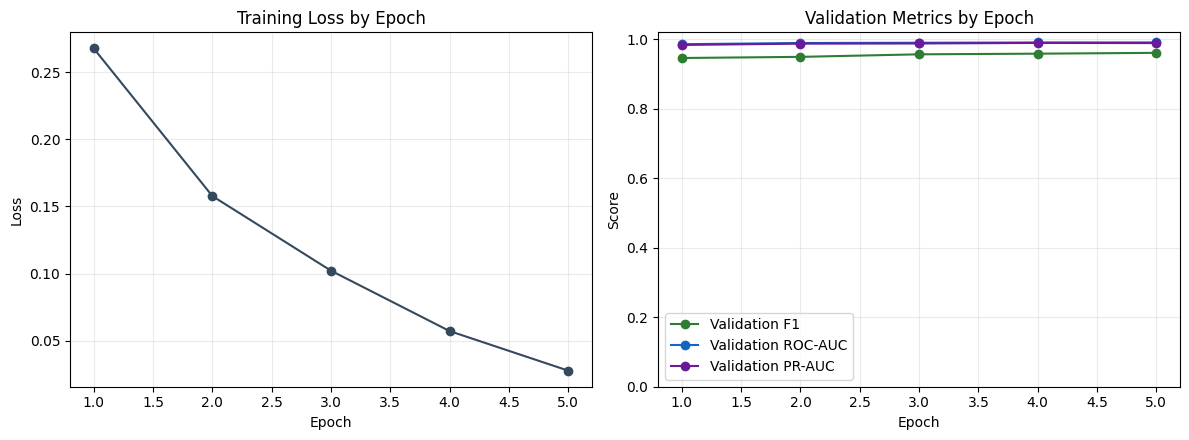

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="#34495e")
axes[0].set_title("Training Loss by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.25)

axes[1].plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Validation F1", color="#2e7d32")
axes[1].plot(history_df["epoch"], history_df["val_roc_auc"], marker="o", label="Validation ROC-AUC", color="#1565c0")
axes[1].plot(history_df["epoch"], history_df["val_pr_auc"], marker="o", label="Validation PR-AUC", color="#6a1b9a")
axes[1].set_title("Validation Metrics by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


### Validation-Based Model Selection

This plot focuses on the criterion used to select the final checkpoint: validation F1. Training loss is shown for comparison, but the selected checkpoint is based on validation performance rather than training loss.


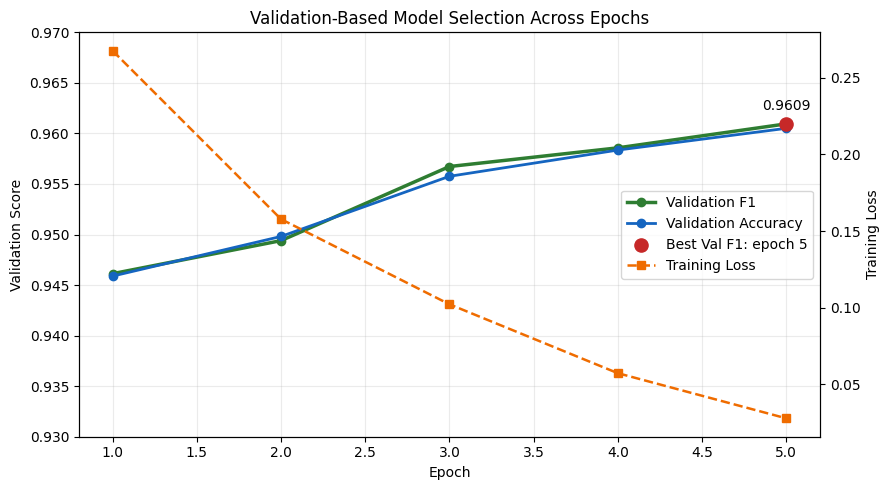

In [21]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    history_df["epoch"],
    history_df["val_f1"],
    marker="o",
    linewidth=2.5,
    label="Validation F1",
    color="#2e7d32",
)
ax1.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    marker="o",
    linewidth=2.0,
    label="Validation Accuracy",
    color="#1565c0",
)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Score")
ax1.set_ylim(0.93, 0.97)
ax1.grid(alpha=0.25)

best_idx = history_df["val_f1"].idxmax()
best_epoch = int(history_df.loc[best_idx, "epoch"])
best_f1 = history_df.loc[best_idx, "val_f1"]
ax1.scatter([best_epoch], [best_f1], color="#c62828", s=90, zorder=5, label=f"Best Val F1: epoch {best_epoch}")
ax1.annotate(f"{best_f1:.4f}", (best_epoch, best_f1), textcoords="offset points", xytext=(0, 10), ha="center")

ax2 = ax1.twinx()
ax2.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="s",
    linestyle="--",
    linewidth=1.8,
    label="Training Loss",
    color="#ef6c00",
)
ax2.set_ylabel("Training Loss")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="center right")

plt.title("Validation-Based Model Selection Across Epochs")
plt.tight_layout()
plt.show()


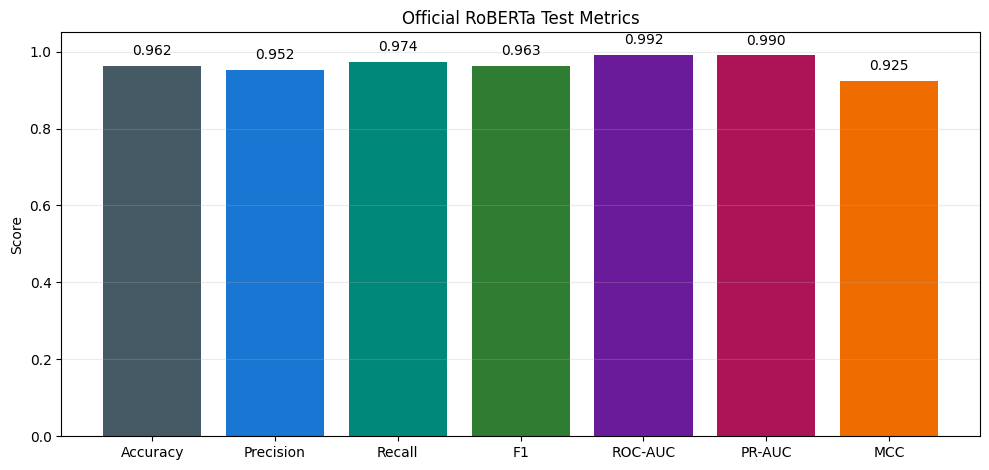

In [17]:
metric_names = ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc", "test_pr_auc", "test_mcc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "MCC"]
metric_values = official_results_df.loc[0, metric_names].astype(float).values

plt.figure(figsize=(10, 4.8))
bars = plt.bar(metric_labels, metric_values, color=["#455a64", "#1976d2", "#00897b", "#2e7d32", "#6a1b9a", "#ad1457", "#ef6c00"])
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Official RoBERTa Test Metrics")
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f"{value:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


c:\Users\ah625\anaconda3\Lib\site-packages\sklearn\utils\_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


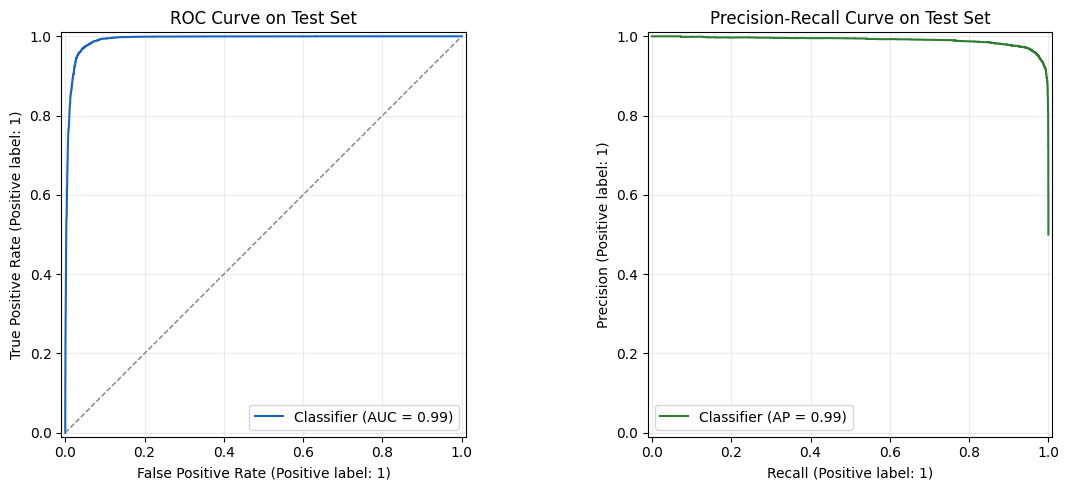

In [18]:
y_true = test_predictions_df["label"].astype(int)
y_score = test_predictions_df["coherent_score"].astype(float)
y_pred = test_predictions_df["prediction"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_true, y_score, ax=axes[0], color="#1565c0")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
axes[0].set_title("ROC Curve on Test Set")
axes[0].grid(alpha=0.25)

PrecisionRecallDisplay.from_predictions(y_true, y_score, ax=axes[1], color="#2e7d32")
axes[1].set_title("Precision-Recall Curve on Test Set")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


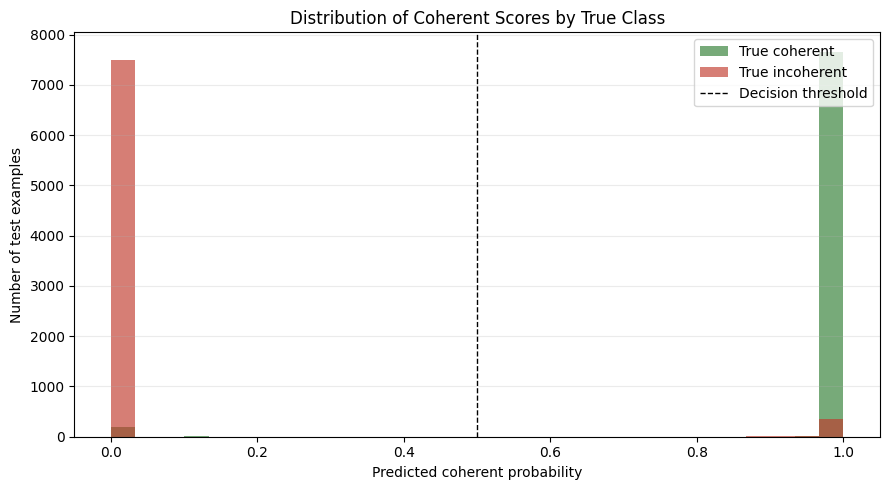

In [19]:
plt.figure(figsize=(9, 5))
plt.hist(
    test_predictions_df.loc[test_predictions_df["label"] == 1, "coherent_score"],
    bins=30,
    alpha=0.65,
    label="True coherent",
    color="#2e7d32",
)
plt.hist(
    test_predictions_df.loc[test_predictions_df["label"] == 0, "coherent_score"],
    bins=30,
    alpha=0.65,
    label="True incoherent",
    color="#c0392b",
)
plt.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold")
plt.xlabel("Predicted coherent probability")
plt.ylabel("Number of test examples")
plt.title("Distribution of Coherent Scores by True Class")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


,Predicted Incoherent,Predicted Coherent
True Incoherent,95.05%,4.95%
True Coherent,2.61%,97.39%


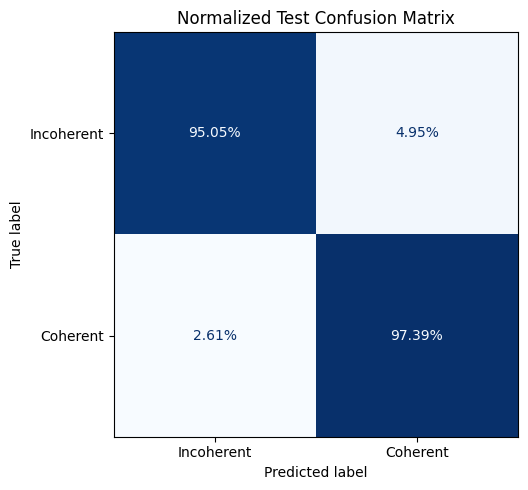

In [20]:
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
cm_norm_df = pd.DataFrame(
    cm_norm,
    index=["True Incoherent", "True Coherent"],
    columns=["Predicted Incoherent", "Predicted Coherent"],
)
display(cm_norm_df.style.format("{:.2%}"))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Incoherent", "Coherent"],
).plot(ax=ax, cmap="Blues", values_format=".2%", colorbar=False)
ax.set_title("Normalized Test Confusion Matrix")
plt.tight_layout()
plt.show()


## Visual Coherence Demo

Use the trained official model on hand-written examples. The coherent score is the model probability for the `Coherent` class. Run this section after training and final evaluation have created `outputs/official_roberta_full/best_model.pt`.


In [9]:
import matplotlib.pyplot as plt
from IPython.display import display

DEMO_MODEL_PATH = OUTPUT_DIR / "best_model.pt"
if not DEMO_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DEMO_MODEL_PATH}. Run the official training cell first."
    )

demo_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR / "tokenizer")
demo_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
demo_model.load_state_dict(torch.load(DEMO_MODEL_PATH, map_location=DEVICE, weights_only=True))
demo_model.to(DEVICE)
demo_model.eval()

print(f"Loaded official model from: {DEMO_MODEL_PATH}")


03:39:12 [INFO] HTTP Request: HEAD https://huggingface.co/roberta-base/resolve/main/config.json "HTTP/1.1 200 OK"
03:39:12 [INFO] HTTP Request: HEAD https://huggingface.co/roberta-base/resolve/main/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded official model from: outputs\official_roberta_full\best_model.pt


In [10]:
demo_examples = [
    {
        "name": "Valid story 1",
        "expected": "Coherent",
        "sentences": [
            "Maya woke up early for her exam.",
            "She reviewed her notes while eating breakfast.",
            "Her father drove her to school on time.",
            "Maya answered every question carefully.",
            "She left the classroom feeling confident.",
        ],
    },
    {
        "name": "Valid story 2",
        "expected": "Coherent",
        "sentences": [
            "Omar planted tomato seeds in a small pot.",
            "He watered the soil every morning.",
            "After two weeks, green shoots appeared.",
            "The plant grew taller throughout the summer.",
            "By August, Omar picked his first tomato.",
        ],
    },
    {
        "name": "Invalid story 1 - shuffled timeline",
        "expected": "Incoherent",
        "sentences": [
            "Maya answered every question carefully.",
            "Maya woke up early for her exam.",
            "She left the classroom feeling confident.",
            "Her father drove her to school on time.",
            "She reviewed her notes while eating breakfast.",
        ],
    },
    {
        "name": "Invalid story 2 - event mismatch",
        "expected": "Incoherent",
        "sentences": [
            "Omar planted tomato seeds in a small pot.",
            "He watered the soil every morning.",
            "The airplane landed during a snowstorm.",
            "The plant grew taller throughout the summer.",
            "By August, Omar picked his first tomato.",
        ],
    },
]


In [11]:
@torch.no_grad()
def predict_coherence(sentences):
    story_text = " [SEP] ".join(sentences)
    encoding = demo_tokenizer(
        story_text,
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
        return_tensors="pt",
    )
    input_ids = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)
    logits = demo_model(input_ids=input_ids, attention_mask=attention_mask).logits
    probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()[0]
    prediction = "Coherent" if probs[1] >= 0.5 else "Incoherent"
    return {
        "prediction": prediction,
        "incoherent_score": float(probs[0]),
        "coherent_score": float(probs[1]),
        "story": story_text,
    }

rows = []
for example in demo_examples:
    result = predict_coherence(example["sentences"])
    rows.append(
        {
            "Example": example["name"],
            "Expected": example["expected"],
            "Prediction": result["prediction"],
            "Coherent score": result["coherent_score"],
            "Incoherent score": result["incoherent_score"],
            "Correct?": example["expected"] == result["prediction"],
        }
    )

demo_results = pd.DataFrame(rows)
display(
    demo_results.style.format(
        {
            "Coherent score": "{:.3f}",
            "Incoherent score": "{:.3f}",
        }
    ).background_gradient(subset=["Coherent score"], cmap="Greens")
)


,Example,Expected,Prediction,Coherent score,Incoherent score,Correct?
0,Valid story 1,Coherent,Coherent,1.000,0.000,True
1,Valid story 2,Coherent,Coherent,1.000,0.000,True
2,Invalid story 1 - shuffled timeline,Incoherent,Incoherent,0.000,1.000,True
3,Invalid story 2 - event mismatch,Incoherent,Coherent,1.000,0.000,False


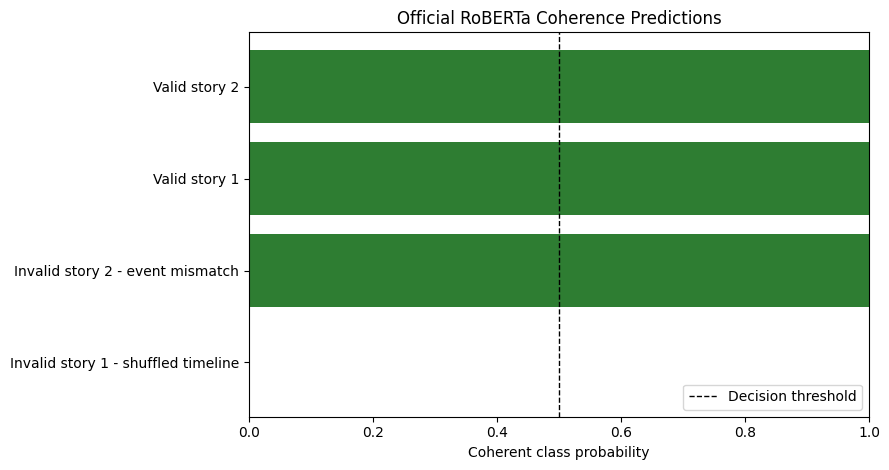

In [12]:
plot_df = demo_results.sort_values("Coherent score")
colors = ["#c0392b" if pred == "Incoherent" else "#2e7d32" for pred in plot_df["Prediction"]]

plt.figure(figsize=(9, 4.8))
plt.barh(plot_df["Example"], plot_df["Coherent score"], color=colors)
plt.axvline(0.5, color="black", linestyle="--", linewidth=1, label="Decision threshold")
plt.xlim(0, 1)
plt.xlabel("Coherent class probability")
plt.title("Official RoBERTa Coherence Predictions")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [13]:
for example in demo_examples:
    print("=" * 80)
    print(example["name"])
    print("Expected:", example["expected"])
    for i, sentence in enumerate(example["sentences"], start=1):
        print(f"{i}. {sentence}")


Valid story 1
Expected: Coherent
1. Maya woke up early for her exam.
2. She reviewed her notes while eating breakfast.
3. Her father drove her to school on time.
4. Maya answered every question carefully.
5. She left the classroom feeling confident.
Valid story 2
Expected: Coherent
1. Omar planted tomato seeds in a small pot.
2. He watered the soil every morning.
3. After two weeks, green shoots appeared.
4. The plant grew taller throughout the summer.
5. By August, Omar picked his first tomato.
Invalid story 1 - shuffled timeline
Expected: Incoherent
1. Maya answered every question carefully.
2. Maya woke up early for her exam.
3. She left the classroom feeling confident.
4. Her father drove her to school on time.
5. She reviewed her notes while eating breakfast.
Invalid story 2 - event mismatch
Expected: Incoherent
1. Omar planted tomato seeds in a small pot.
2. He watered the soil every morning.
3. The airplane landed during a snowstorm.
4. The plant grew taller throughout the summe